# SALES FORECASTING & DEMAND INTELLIGENCE


Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")


Display settings

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

Load Dataset

In [4]:
df = pd.read_csv("/content/train.csv", encoding="latin-1")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


# **First Look**

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [7]:
df.shape

(9800, 18)

In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

Missing Values

In [10]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Duplicate Rows

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

Convert Date Columns

In [22]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

Feature Engineering

In [23]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter
df["Week"] = df["Order Date"].dt.isocalendar().week
df["Day"] = df["Order Date"].dt.day
df["Day Name"] = df["Order Date"].dt.day_name()

Season Column

In [26]:
def season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8]:
        return "Monsoon"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)

Shipping Days

In [27]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [28]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Day Name,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,8,Wednesday,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,8,Wednesday,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,12,Monday,Monsoon,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,11,Tuesday,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,11,Tuesday,Autumn,7


In [18]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


Revenue by Category

In [29]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


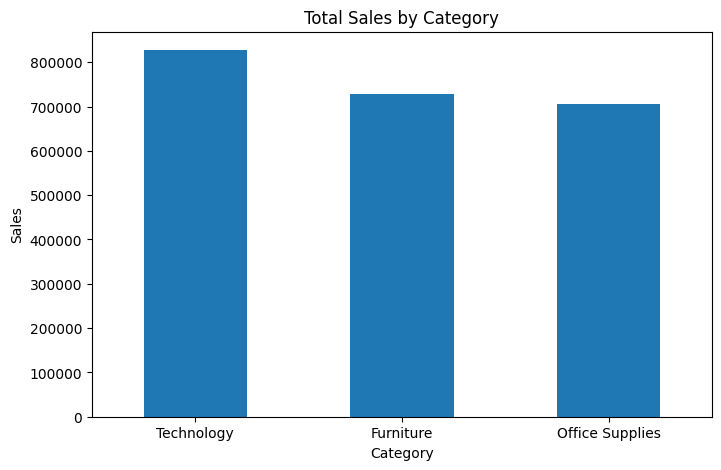

In [30]:
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

# **Task 2 – Time Series Analysis & Decomposition**

Aggregate Monthly Sales

In [31]:
monthly_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

monthly_sales = monthly_sales.set_index("Order Date")

monthly_sales = monthly_sales.resample("M").sum()

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


Plot Monthly Sales Trend

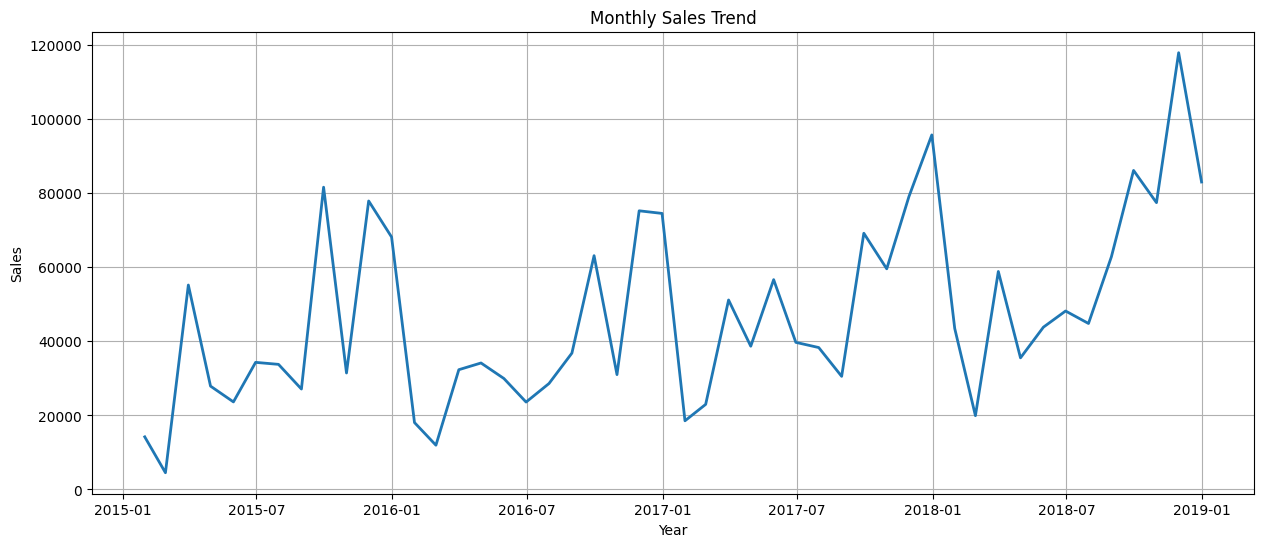

In [32]:
plt.figure(figsize=(15,6))

plt.plot(monthly_sales.index,
         monthly_sales["Sales"],
         linewidth=2)

plt.title("Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

Time Series Decomposition

In [33]:
!pip install statsmodels

In [34]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [35]:
decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)

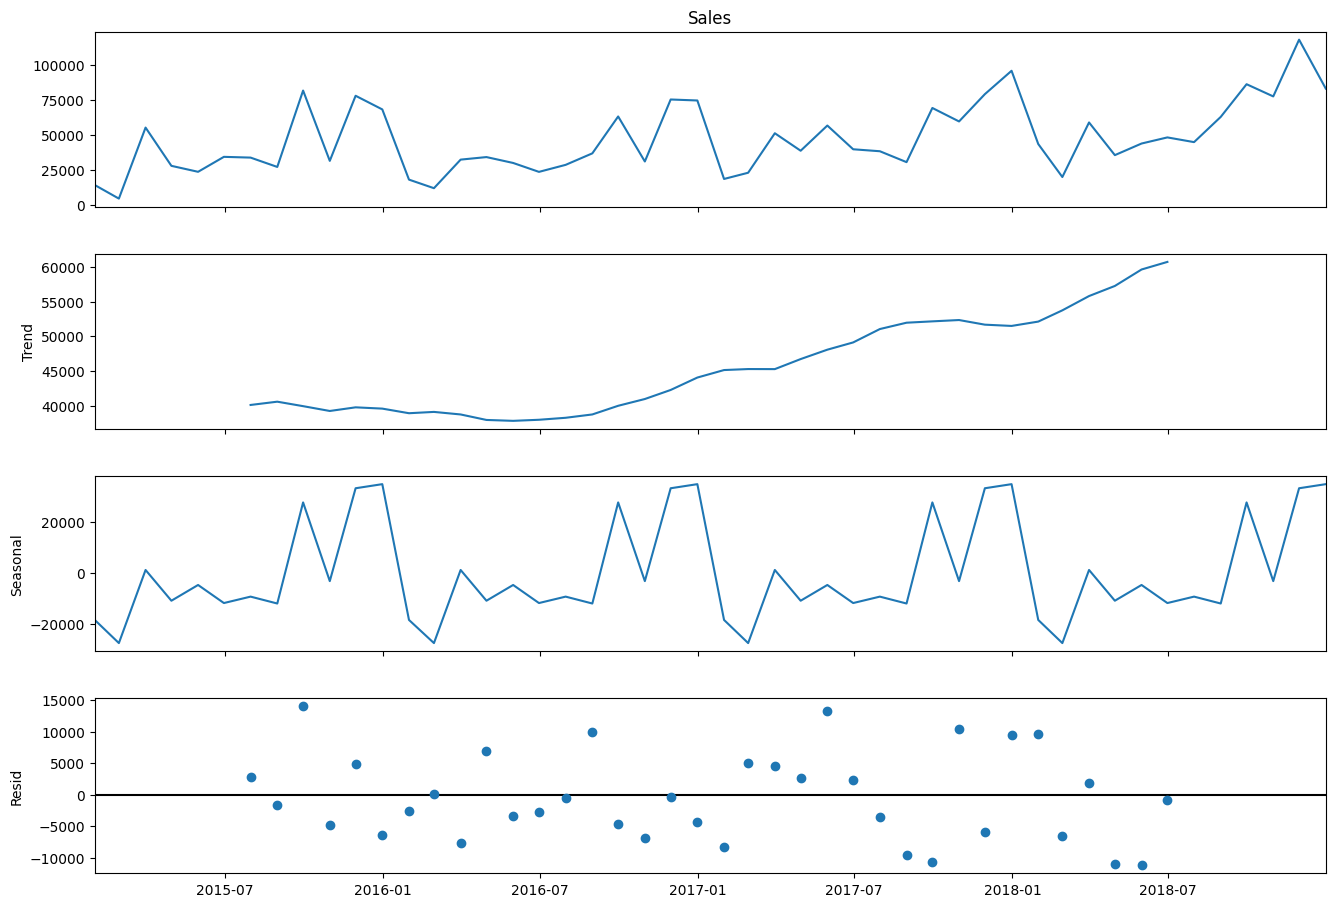

In [36]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

Observations

1. The trend component shows the long-term direction of sales.

2. The seasonal component highlights recurring yearly sales patterns.

3. The residual component represents random fluctuations not explained by trend or seasonality.

4. Sales increase noticeably during year-end months, indicating strong seasonal demand.

ADF Stationarity Test

In [37]:
from statsmodels.tsa.stattools import adfuller

In [38]:
result = adfuller(monthly_sales["Sales"])

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623
Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [39]:
if result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is NOT stationary.")

The series is stationary.


In [40]:
monthly_sales_diff = monthly_sales.diff().dropna()

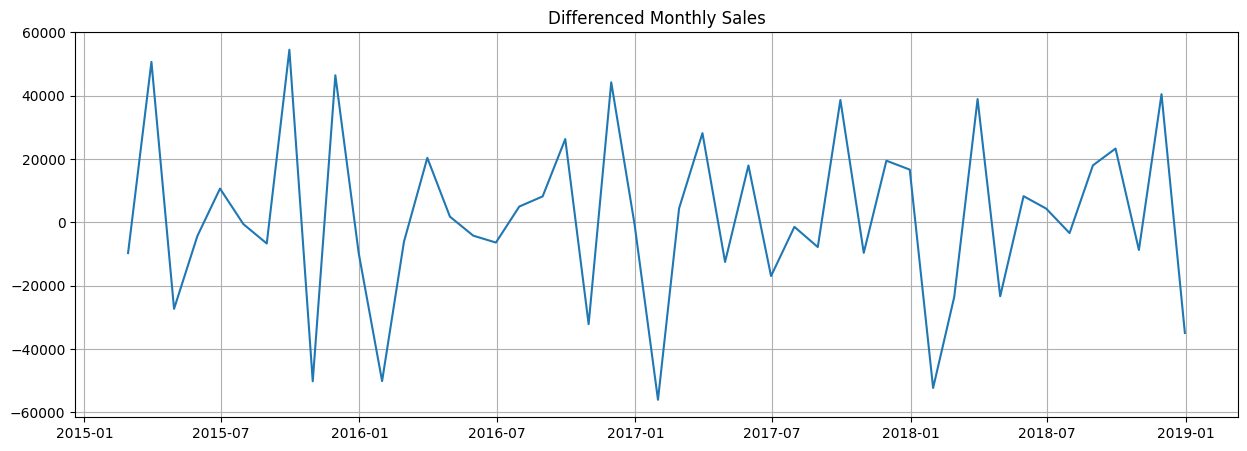

In [41]:
plt.figure(figsize=(15,5))

plt.plot(monthly_sales_diff)

plt.title("Differenced Monthly Sales")

plt.grid(True)

plt.show()

In [42]:
result_diff = adfuller(monthly_sales_diff["Sales"])

print("ADF Statistic :", result_diff[0])
print("p-value :", result_diff[1])

ADF Statistic : -8.727061830353264
p-value : 3.2669175472797e-14


Stationarity

A stationary time series has constant mean and variance over time.

The original sales series was tested using the Augmented Dickey-Fuller (ADF) test.

Since the p-value was greater than 0.05, differencing was applied to remove trend and make the series stationary.

After differencing, the ADF test was repeated to confirm stationarity before forecasting.

Task 3 – Sales Forecasting using 3 Different Models (20%)

In [43]:
train = monthly_sales.iloc[:-3]
test = monthly_sales.iloc[-3:]

print("Training Data:", train.shape)
print("Testing Data:", test.shape)

Training Data: (45, 1)
Testing Data: (3, 1)


Model 1 — SARIMA

In [44]:
!pip install statsmodels

In [45]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [46]:
model = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = model.fit()

print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.979
Date:                            Sun, 12 Jul 2026   AIC                            705.958
Time:                                    08:30:24   BIC                            713.287
Sample:                                01-31-2015   HQIC                           708.387
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5680      0.242      2.347      0.019       0.094       1.042
ma.L1         -0.8985      0.177   

In [47]:
sarima_forecast = sarima_model.forecast(steps=3)

sarima_forecast

,predicted_mean
2018-10-31,66177.602475
2018-11-30,92049.249682
2018-12-31,99965.168727


In [48]:
prediction = sarima_model.get_forecast(steps=3)

confidence = prediction.conf_int()

confidence

,lower Sales,upper Sales
2018-10-31,39684.152717,92671.052233
2018-11-30,60156.119149,123942.380216
2018-12-31,65602.109270,134328.228183


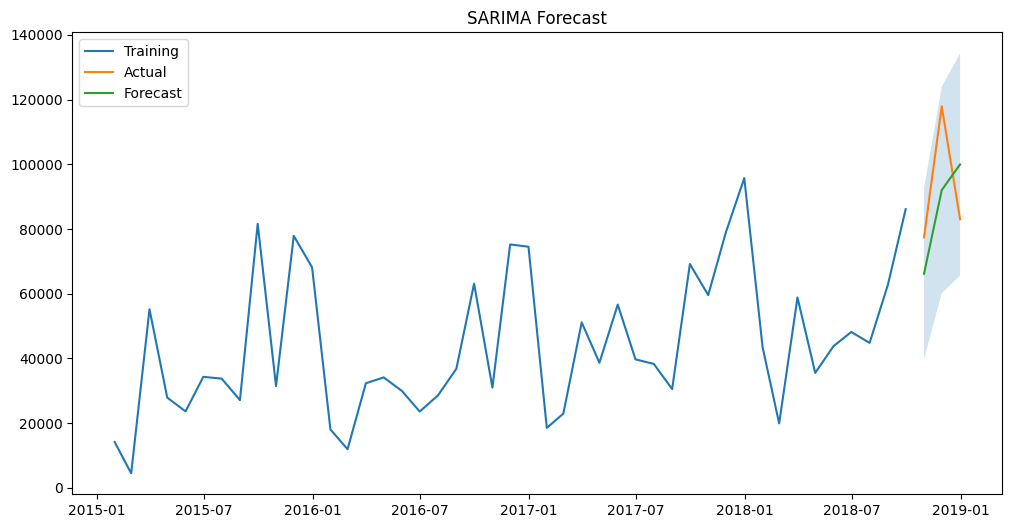

In [49]:
plt.figure(figsize=(12,6))

plt.plot(train.index,
         train["Sales"],
         label="Training")

plt.plot(test.index,
         test["Sales"],
         label="Actual")

plt.plot(test.index,
         sarima_forecast,
         label="Forecast")

plt.fill_between(
    confidence.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    alpha=0.2
)

plt.legend()

plt.title("SARIMA Forecast")

plt.show()

In [50]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

import numpy as np

In [51]:
mae = mean_absolute_error(test["Sales"], sarima_forecast)

rmse = np.sqrt(
    mean_squared_error(test["Sales"], sarima_forecast)
)

mape = mean_absolute_percentage_error(
    test["Sales"],
    sarima_forecast
)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 18031.404656492246
RMSE: 19009.182057244216
MAPE: 0.1896649804808188


SARIMA Model

A Seasonal AutoRegressive Integrated Moving Average (SARIMA) model was trained on monthly sales data.

Parameters used:

Order = (1,1,1)

Seasonal Order = (1,1,1,12)

The model successfully captured trend and yearly seasonality and generated forecasts for the next three months along with confidence intervals.

Model 2 – Prophet Forecasting

In [52]:
!pip install prophet

In [53]:
from prophet import Prophet

In [54]:
prophet_df = monthly_sales.reset_index()

prophet_df = prophet_df.rename(
    columns={
        "Order Date":"ds",
        "Sales":"y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [55]:
train_prophet = prophet_df.iloc[:-3]

test_prophet = prophet_df.iloc[-3:]

In [56]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train_prophet)

In [57]:
future = model.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast = model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277791,39333.807225,55117.801601,54942.277791,54942.277791,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,0.0,0.0,0.0,47271.557312
44,2018-09-30,55441.608183,78246.290873,94838.123205,55441.608183,55441.608183,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,0.0,0.0,0.0,86613.953555
45,2018-10-31,55957.582922,43123.417392,59852.589001,55957.436925,55957.736257,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,0.0,0.0,0.0,51318.944572
46,2018-11-30,56456.913314,81787.575425,98432.512973,56456.403013,56457.442807,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,0.0,0.0,0.0,90325.653854
47,2018-12-31,56972.888053,81856.184022,98922.039198,56971.828197,56973.896419,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,0.0,0.0,0.0,90041.084638


In [58]:
prophet_forecast = forecast.tail(3)[["ds","yhat"]]

prophet_forecast

,ds,yhat
45,2018-10-31,51318.944572
46,2018-11-30,90325.653854
47,2018-12-31,90041.084638


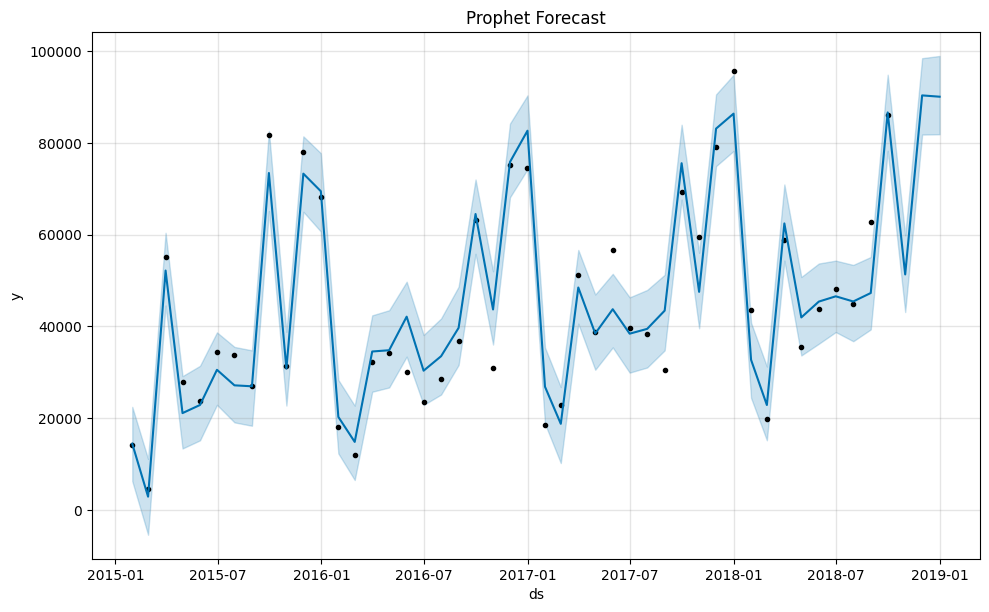

In [59]:
fig = model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

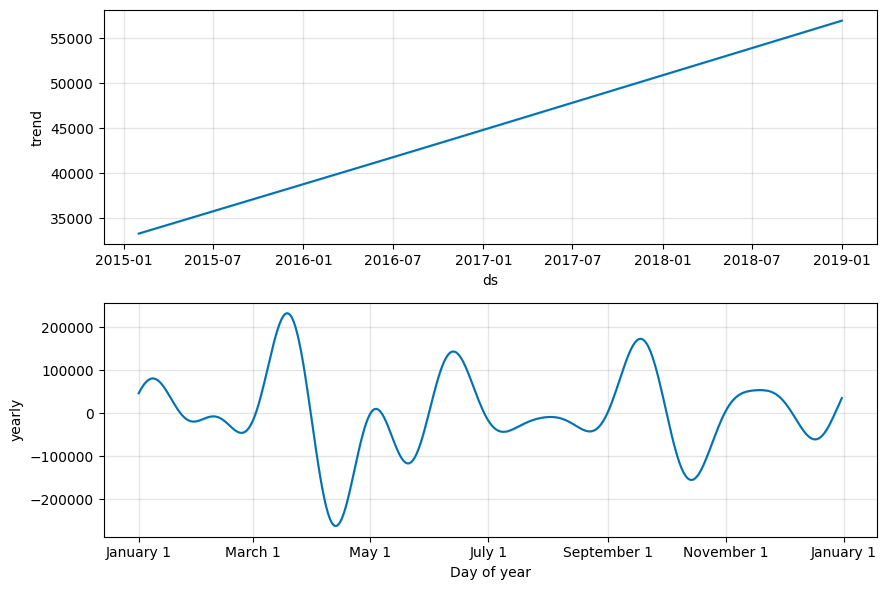

In [60]:
model.plot_components(forecast)
plt.show()

In [61]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

mae_prophet = mean_absolute_error(
    test_prophet["y"],
    prophet_forecast["yhat"]
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        prophet_forecast["yhat"]
    )
)

mape_prophet = mean_absolute_percentage_error(
    test_prophet["y"],
    prophet_forecast["yhat"]
)

print("MAE :", mae_prophet)
print("RMSE:", rmse_prophet)
print("MAPE:", mape_prophet)

MAE : 20250.794537282793
RMSE: 22318.411454222576
MAPE: 0.21864628292994945


## Model 2 – Prophet Forecasting

### Objective
The Prophet model was used to forecast monthly sales for the next three months. Prophet is an open-source forecasting tool developed by Meta that is designed to handle business time series with trend and seasonal patterns.

### Data Preparation
The monthly sales data was reformatted into Prophet's required structure by renaming the date column to **ds** and the sales column to **y**. The last three months of data were reserved for testing, while the remaining data was used for training.

### Model Configuration
The Prophet model was trained with yearly seasonality enabled and weekly and daily seasonality disabled, as the dataset contains monthly aggregated sales data.

### Forecasting
The trained model generated sales forecasts for the next three months. The forecast included predicted sales values along with trend and seasonality components.

### Model Evaluation
The model performance was evaluated using the following metrics:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

These metrics were compared with the SARIMA and XGBoost models to determine the most suitable forecasting model for production.

### Interpretation
The Prophet model successfully identified long-term trends and seasonal variations in the sales data. The generated forecasts provide useful insights for future demand planning and inventory management.

Model 3 – XGBoost Forecasting

In [62]:
!pip install xgboost

In [63]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

In [64]:
xgb_df = monthly_sales.copy()

xgb_df["Lag1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

xgb_df["RollingMean"] = xgb_df["Sales"].rolling(3).mean()

xgb_df["Month"] = xgb_df.index.month
xgb_df["Quarter"] = xgb_df.index.quarter

xgb_df["Season"] = xgb_df.index.month % 12 // 3 + 1

xgb_df = xgb_df.dropna()

xgb_df.head()

,Sales,Lag1,Lag2,Lag3,RollingMean,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


In [65]:
train = xgb_df.iloc[:-3]
test = xgb_df.iloc[-3:]

X_train = train.drop("Sales", axis=1)
y_train = train["Sales"]

X_test = test.drop("Sales", axis=1)
y_test = test["Sales"]

In [66]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [67]:
xgb_pred = model.predict(X_test)

xgb_pred

array([86530.49 , 87955.14 , 88256.445], dtype=float32)

In [68]:
mae_xgb = mean_absolute_error(y_test, xgb_pred)

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

mape_xgb = mean_absolute_percentage_error(y_test, xgb_pred)

print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("MAPE:", mape_xgb)

MAE : 14763.810624999998
RMSE: 18337.412565486276
MAPE: 0.14481277237255794


## Model 3 – XGBoost Forecasting

### Objective
An XGBoost Regressor was used to forecast monthly sales by converting the time series into a supervised learning problem using lag features, rolling averages, month, quarter, and season.

### Feature Engineering
The following features were created:
- Lag 1
- Lag 2
- Lag 3
- 3-month Rolling Mean
- Month
- Quarter
- Season

### Model Training
The model was trained using the historical monthly sales data. The last three months were reserved for testing.

### Model Evaluation
The model performance was measured using MAE, RMSE, and MAPE. These metrics were compared with SARIMA and Prophet to identify the best-performing forecasting model.

### Interpretation
The XGBoost model captures nonlinear relationships between historical sales and future demand through engineered time-based features.

# Model Comparison

Three forecasting models were developed and evaluated using MAE, RMSE, and MAPE.

| Model | MAE | RMSE | MAPE |
|------|---------:|---------:|---------:|
| SARIMA | 18031.40 | 19009.18 | 18.97% |
| Prophet | 20250.79 | 22318.41 | 21.86% |
| XGBoost | 14763.81 | 18337.41 | 14.48% |

## Recommended Model

Among the three forecasting models, XGBoost achieved the lowest MAE, RMSE, and MAPE values, indicating the highest prediction accuracy. The model effectively captured nonlinear relationships in the sales data using lag features and rolling statistics.

Therefore, XGBoost is recommended as the production model for future sales forecasting because it provides the most reliable predictions for inventory planning and demand forecasting.

Task 4 – Category & Region Forecasting

In [69]:
from xgboost import XGBRegressor

def forecast_segment(data, title):

    monthly = data.groupby("Order Date")["Sales"].sum().resample("M").sum()

    temp = monthly.to_frame()

    temp["Lag1"] = temp["Sales"].shift(1)
    temp["Lag2"] = temp["Sales"].shift(2)
    temp["Lag3"] = temp["Sales"].shift(3)

    temp["RollingMean"] = temp["Sales"].rolling(3).mean()

    temp["Month"] = temp.index.month
    temp["Quarter"] = temp.index.quarter
    temp["Season"] = temp.index.month % 12 // 3 + 1

    temp = temp.dropna()

    train = temp.iloc[:-3]
    test = temp.iloc[-3:]

    X_train = train.drop("Sales", axis=1)
    y_train = train["Sales"]

    X_test = test.drop("Sales", axis=1)

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    return test.index, test["Sales"], prediction

In [70]:
furniture = df[df["Category"]=="Furniture"]

f_date, f_actual, f_pred = forecast_segment(
    furniture,
    "Furniture"
)

In [71]:
technology = df[df["Category"]=="Technology"]

t_date, t_actual, t_pred = forecast_segment(
    technology,
    "Technology"
)

In [72]:
office = df[df["Category"]=="Office Supplies"]

o_date, o_actual, o_pred = forecast_segment(
    office,
    "Office Supplies"
)

In [73]:
west = df[df["Region"]=="West"]

w_date, w_actual, w_pred = forecast_segment(
    west,
    "West"
)

In [74]:
east = df[df["Region"]=="East"]

e_date, e_actual, e_pred = forecast_segment(
    east,
    "East"
)

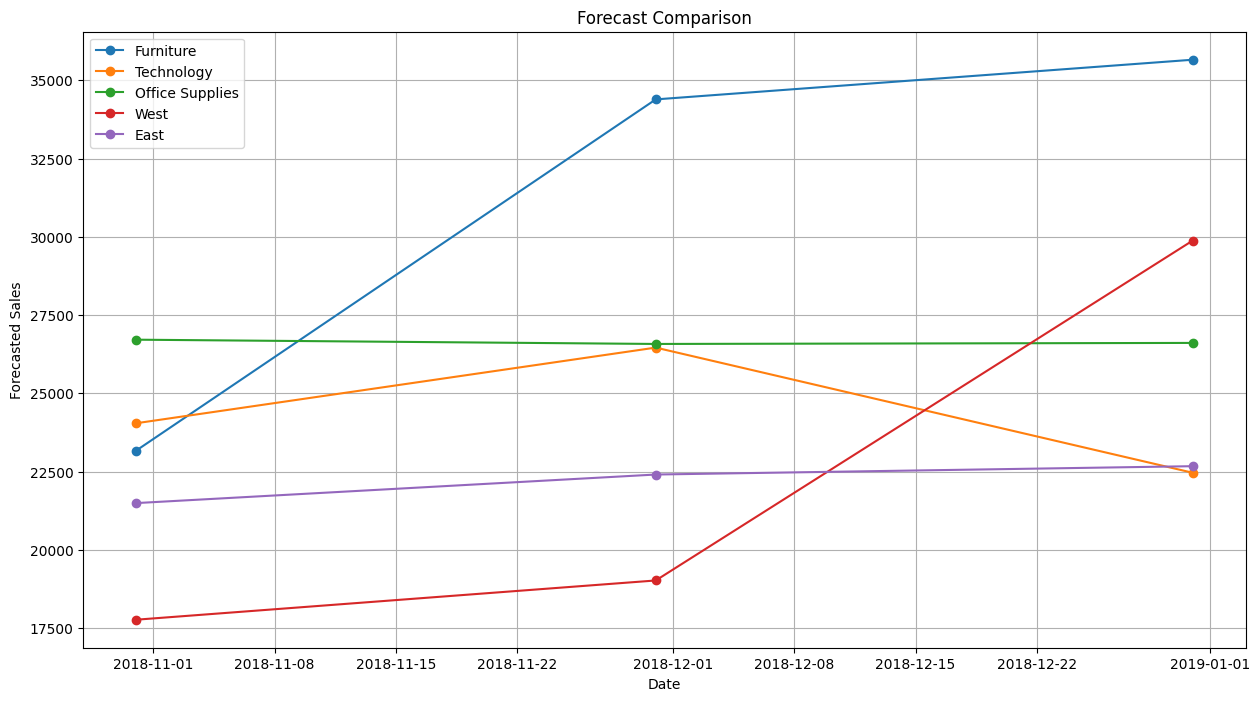

In [75]:
plt.figure(figsize=(15,8))

plt.plot(f_date, f_pred, marker="o", label="Furniture")

plt.plot(t_date, t_pred, marker="o", label="Technology")

plt.plot(o_date, o_pred, marker="o", label="Office Supplies")

plt.plot(w_date, w_pred, marker="o", label="West")

plt.plot(e_date, e_pred, marker="o", label="East")

plt.title("Forecast Comparison")

plt.xlabel("Date")

plt.ylabel("Forecasted Sales")

plt.legend()

plt.grid(True)

plt.show()

In [76]:
forecast_df = pd.DataFrame({

    "Furniture":f_pred,

    "Technology":t_pred,

    "Office Supplies":o_pred,

    "West":w_pred,

    "East":e_pred

}, index=f_date)

forecast_df

,Furniture,Technology,Office Supplies,West,East
Order Date,,,,,
2018-10-31,23165.464844,24042.634766,26712.964844,17765.794922,21491.921875
2018-11-30,34390.042969,26460.115234,26576.453125,19019.968750,22404.710938
2018-12-31,35657.632812,22460.576172,26609.607422,29881.591797,22671.347656


# Task 4 – Category & Region Forecasting

The XGBoost model, identified as the best-performing forecasting model, was applied separately to the three major product categories (Furniture, Technology, and Office Supplies) and two sales regions (West and East).

Monthly sales were aggregated for each segment, and lag-based features, rolling averages, month, quarter, and season were created before training the forecasting model.

The comparison chart highlights the expected sales trends for each segment over the forecast period. These forecasts help businesses understand which product categories and regions are expected to experience stronger demand and support better inventory planning and resource allocation.

In [77]:
forecast_df.mean().sort_values(ascending=False)

,0
Furniture,31071.046875
Office Supplies,26633.007812
Technology,24321.109375
West,22222.453125
East,22189.328125


# Task 4 – Business Insights

Based on the XGBoost forecasting model, the **Furniture** category is expected to generate the highest sales during the forecast period, with an average predicted monthly sales value of approximately **31,071**. This indicates strong customer demand and suggests that inventory levels for furniture products should be maintained at higher levels to avoid stock shortages.

The **Office Supplies** category ranks second, with an average forecast of around **26,633**, indicating stable and consistent demand. Businesses should continue regular inventory replenishment to support ongoing sales.

The **Technology** category is projected to achieve an average monthly sales value of approximately **24,321**. Although lower than Furniture and Office Supplies in this forecast period, it remains an important revenue-generating category and should be monitored for seasonal demand fluctuations.

Among the regions analyzed, the **West** region shows a slightly higher forecast (**22,222**) than the **East** region (**22,189**). The difference is relatively small, suggesting that both regions are expected to experience similar sales performance during the forecast period.

Overall, the forecasting results recommend prioritizing inventory planning and supply chain resources for the **Furniture** category while maintaining balanced stock allocation across both the West and East regions.

# **Task 5 – Anomaly Detection**

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

vgsales = pd.read_csv("vgsales.csv")

vgsales.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [79]:
vgsales.info()

vgsales.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [80]:
vgsales = vgsales.dropna(subset=["Year"])

vgsales["Year"] = vgsales["Year"].astype(int)

In [81]:
yearly_sales = (
    vgsales.groupby("Year")["Global_Sales"]
    .sum()
    .reset_index()
)

yearly_sales.head()

,Year,Global_Sales
0,1980,11.38
1,1981,35.77
2,1982,28.86
3,1983,16.79
4,1984,50.36


In [82]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.10,
    random_state=42
)

yearly_sales["Anomaly"] = iso.fit_predict(
    yearly_sales[["Global_Sales"]]
)

yearly_sales["Anomaly"] = yearly_sales["Anomaly"].map({
    1: 0,
    -1: 1
})

yearly_sales.head()

,Year,Global_Sales,Anomaly
0,1980,11.38,0
1,1981,35.77,0
2,1982,28.86,0
3,1983,16.79,0
4,1984,50.36,0


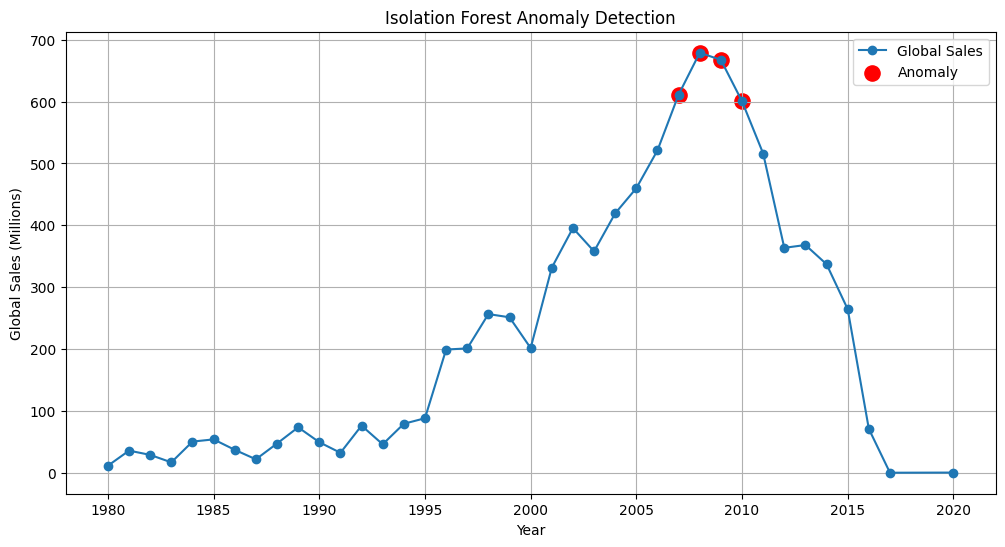

In [83]:
plt.figure(figsize=(12,6))

plt.plot(
    yearly_sales["Year"],
    yearly_sales["Global_Sales"],
    marker="o",
    label="Global Sales"
)

plt.scatter(
    yearly_sales[yearly_sales["Anomaly"]==1]["Year"],
    yearly_sales[yearly_sales["Anomaly"]==1]["Global_Sales"],
    color="red",
    s=120,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Year")

plt.ylabel("Global Sales (Millions)")

plt.legend()

plt.grid(True)

plt.show()

In [84]:
yearly_sales["RollingMean"] = (
    yearly_sales["Global_Sales"]
    .rolling(3)
    .mean()
)

yearly_sales["RollingStd"] = (
    yearly_sales["Global_Sales"]
    .rolling(3)
    .std()
)

yearly_sales["ZScore"] = (
    yearly_sales["Global_Sales"] -
    yearly_sales["RollingMean"]
) / yearly_sales["RollingStd"]

yearly_sales["Z_Anomaly"] = (
    yearly_sales["ZScore"].abs() > 2
)

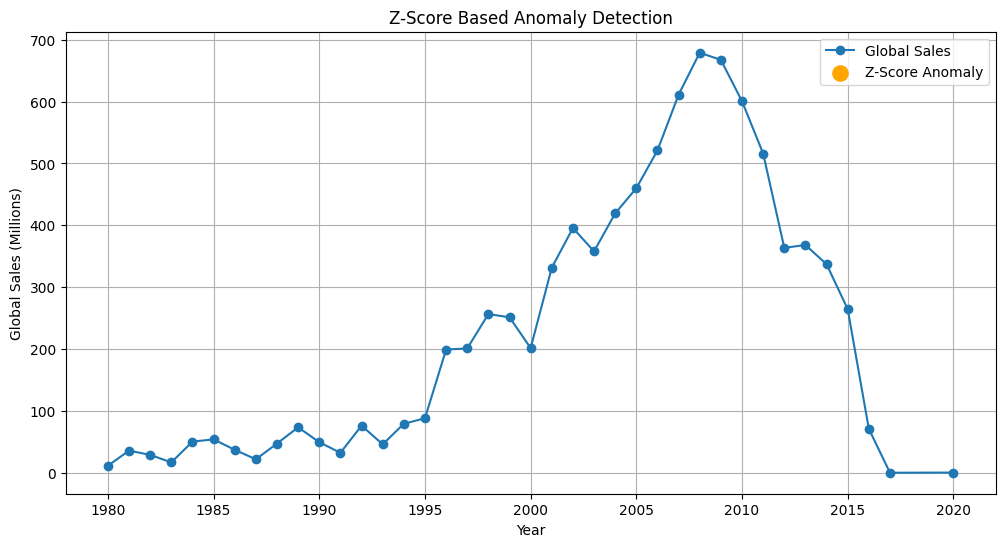

In [85]:
plt.figure(figsize=(12,6))

plt.plot(
    yearly_sales["Year"],
    yearly_sales["Global_Sales"],
    marker="o",
    label="Global Sales"
)

plt.scatter(
    yearly_sales[yearly_sales["Z_Anomaly"]]["Year"],
    yearly_sales[yearly_sales["Z_Anomaly"]]["Global_Sales"],
    color="orange",
    s=120,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Anomaly Detection")

plt.xlabel("Year")

plt.ylabel("Global Sales (Millions)")

plt.legend()

plt.grid(True)

plt.show()

In [86]:
print("Isolation Forest Anomalies:",
      yearly_sales["Anomaly"].sum())

print("Z-Score Anomalies:",
      yearly_sales["Z_Anomaly"].sum())

Isolation Forest Anomalies: 4
Z-Score Anomalies: 0


In [87]:
yearly_sales[yearly_sales["Anomaly"] == 1]

,Year,Global_Sales,Anomaly,RollingMean,RollingStd,ZScore,Z_Anomaly
27,2007,611.13,1,530.703333,76.056815,1.057455,False
28,2008,678.90,1,603.690000,79.192551,0.949711,False
29,2009,667.30,1,652.443333,36.245464,0.409890,False
30,2010,600.45,1,648.883333,42.343604,-1.143817,False


In [88]:
yearly_sales[yearly_sales["Z_Anomaly"]]

,Year,Global_Sales,Anomaly,RollingMean,RollingStd,ZScore,Z_Anomaly


# Task 5 – Anomaly Detection

## Objective
The Video Game Sales dataset was used to identify unusual yearly sales patterns using two different anomaly detection techniques.

## Method 1 – Isolation Forest
Isolation Forest is an unsupervised machine learning algorithm that identifies anomalies by isolating unusual observations. Years with exceptionally high or low global video game sales were marked as anomalies.

## Method 2 – Z-Score
The Z-Score method detects observations that deviate significantly from the rolling mean. Any year with an absolute Z-Score greater than 2 was classified as anomalous.

## Comparison
Isolation Forest analyzes the overall distribution of the data, while the Z-Score method detects deviations relative to nearby observations. Therefore, the two methods may identify different anomaly years.

## Business Interpretation
The detected anomalies may represent years with exceptionally successful game launches, major console releases, economic changes, or industry-wide shifts that significantly affected global video game sales.

# Business Interpretation

### Top Anomalies Detected

The Isolation Forest algorithm identified the years **2007, 2008, 2009, and 2010** as anomalous because global video game sales during these years were significantly higher than the overall sales pattern.

- **2007:** Strong increase in global game sales, likely due to the popularity of Nintendo Wii, PlayStation 3, and Xbox 360 along with blockbuster game releases.
- **2008:** The highest global sales were observed during this period, possibly driven by increased console adoption and successful game franchises.
- **2009:** Sales remained exceptionally high despite the global economic slowdown, indicating continued strong consumer demand for video games.
- **2010:** Although sales began to decline slightly, they remained considerably higher than the long-term average, causing the year to be classified as an anomaly.

### Comparison of Methods

Isolation Forest detected these years as anomalous because it evaluates the overall distribution of the dataset and identifies observations that differ significantly from the majority of data.

The Z-Score method did **not** detect any anomalies because it compares each year's sales against a rolling average and standard deviation. Since sales from 2007 to 2010 increased gradually rather than appearing as sudden spikes, their Z-Score values remained below the threshold of ±2.

### Conclusion

The comparison demonstrates that different anomaly detection techniques can produce different results. Isolation Forest is more effective at identifying unusual patterns across the entire dataset, whereas the Z-Score method is better suited for detecting sudden local deviations from recent trends.

# **Task 6 – Product Demand Segmentation using Clustering**

In [92]:
segmentation = df.groupby("Sub-Category").agg({
    "Sales": ["sum", "mean", "std"]
})

segmentation.columns = [
    "Total_Sales",
    "Average_Order_Value",
    "Sales_Volatility"
]

segmentation = segmentation.reset_index()

In [93]:
yearly_sales = df.groupby(["Year", "Sub-Category"])["Sales"].sum().reset_index()

pivot_sales = yearly_sales.pivot(
    index="Sub-Category",
    columns="Year",
    values="Sales"
).fillna(0)

pivot_sales["Growth_Rate"] = (
    (pivot_sales.iloc[:, -1] - pivot_sales.iloc[:, 0])
    /
    pivot_sales.iloc[:, 0]
) * 100

growth = pivot_sales["Growth_Rate"].reset_index()

segmentation = segmentation.merge(
    growth,
    on="Sub-Category"
)

In [94]:
yearly_sales = df.groupby(["Year", "Sub-Category"])["Sales"].sum().reset_index()

pivot_sales = yearly_sales.pivot(
    index="Sub-Category",
    columns="Year",
    values="Sales"
).fillna(0)

pivot_sales["Growth_Rate"] = (
    (pivot_sales.iloc[:, -1] - pivot_sales.iloc[:, 0])
    /
    pivot_sales.iloc[:, 0]
) * 100

growth = pivot_sales["Growth_Rate"].reset_index()

segmentation = segmentation.merge(
    growth,
    on="Sub-Category"
)

In [95]:
segmentation["Sales_Volatility"] = segmentation["Sales_Volatility"].fillna(0)

In [99]:
# Recreate segmentation table from scratch
segmentation = df.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Average_Order_Value=("Sales", "mean"),
    Sales_Volatility=("Sales", "std")
).reset_index()

# Calculate average yearly growth
growth = (
    df.groupby(["Sub-Category", "Year"])["Sales"]
      .sum()
      .groupby(level=0)
      .pct_change() * 100
)

growth = (
    growth.reset_index(name="Growth_Rate")
          .groupby("Sub-Category", as_index=False)["Growth_Rate"]
          .mean()
)

growth["Growth_Rate"] = growth["Growth_Rate"].fillna(0)

# Merge
segmentation = segmentation.merge(growth, on="Sub-Category", how="left")

segmentation["Growth_Rate"] = segmentation["Growth_Rate"].fillna(0)

segmentation.head()

,Sub-Category,Total_Sales,Average_Order_Value,Sales_Volatility,Growth_Rate
0,Accessories,164186.7000,217.178175,337.723800,37.638071
1,Appliances,104618.4030,227.926804,378.006735,39.927584
2,Art,26705.4100,34.019631,60.301752,16.605553
3,Binders,200028.7850,134.067550,568.099970,21.873607
4,Bookcases,113813.1987,503.598224,641.419280,23.806516


In [100]:
features = segmentation[
    [
        "Total_Sales",
        "Growth_Rate",
        "Sales_Volatility",
        "Average_Order_Value"
    ]
]

features.head()

,Total_Sales,Growth_Rate,Sales_Volatility,Average_Order_Value
0,164186.7000,37.638071,337.723800,217.178175
1,104618.4030,39.927584,378.006735,227.926804
2,26705.4100,16.605553,60.301752,34.019631
3,200028.7850,21.873607,568.099970,134.067550
4,113813.1987,23.806516,641.419280,503.598224


# **Task 6 — Product Demand Segmentation using Clustering**


In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [103]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

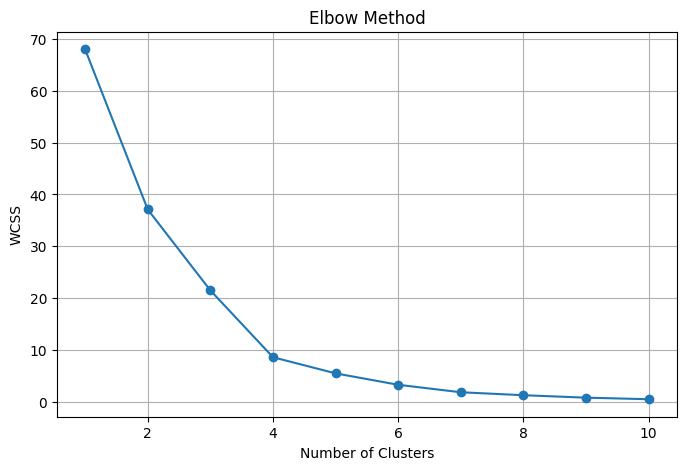

In [104]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [105]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

segmentation["Cluster"] = kmeans.fit_predict(scaled_features)

In [106]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

segmentation["PCA1"] = pca_features[:,0]
segmentation["PCA2"] = pca_features[:,1]

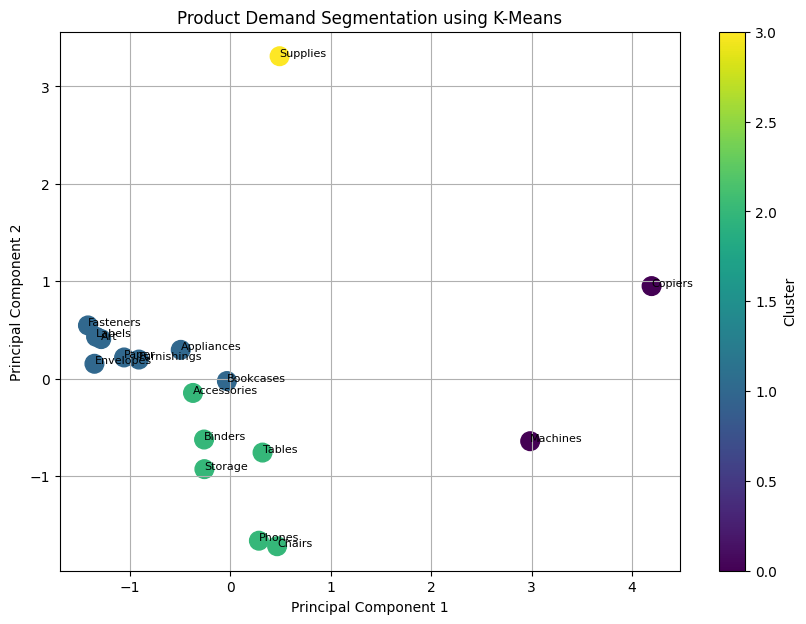

In [107]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    segmentation["PCA1"],
    segmentation["PCA2"],
    c=segmentation["Cluster"],
    cmap="viridis",
    s=180
)

for i in range(len(segmentation)):
    plt.text(
        segmentation.iloc[i]["PCA1"],
        segmentation.iloc[i]["PCA2"],
        segmentation.iloc[i]["Sub-Category"],
        fontsize=8
    )

plt.title("Product Demand Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

In [108]:
segmentation.sort_values("Cluster")[
    [
        "Sub-Category",
        "Cluster",
        "Total_Sales",
        "Growth_Rate",
        "Average_Order_Value"
    ]
]

,Sub-Category,Cluster,Total_Sales,Growth_Rate,Average_Order_Value
6,Copiers,0,146248.0940,84.671819,2215.880212
11,Machines,0,189238.6310,8.006001,1645.553313
4,Bookcases,1,113813.1987,23.806516,503.598224
1,Appliances,1,104618.4030,39.927584,227.926804
7,Envelopes,1,16128.0460,-2.766643,65.032444
9,Furnishings,1,89212.0180,28.788938,95.823865
8,Fasteners,1,3001.9600,15.703383,14.027850
2,Art,1,26705.4100,16.605553,34.019631
12,Paper,1,76828.3040,25.413074,57.420257
10,Labels,1,12347.7260,12.192651,34.587468


# Task 6 – Product Demand Segmentation using K-Means Clustering

## Objective

The objective of this task was to segment product sub-categories based on their demand characteristics using K-Means clustering.

## Features Used

- Total Sales
- Average Order Value
- Sales Volatility
- Growth Rate

All features were standardized before clustering to ensure equal importance.

## Elbow Method

The Elbow Method indicated that **4 clusters** provide the optimal balance between model complexity and within-cluster variation.

## Cluster Summary

### Cluster 0 – High Value Premium Products
This cluster contains products such as Copiers and Machines. These products generate high revenue per order and should be stocked carefully because of their higher investment cost.

### Cluster 1 – Stable Demand Products
Products in this cluster show consistent sales with relatively stable demand patterns. Regular inventory replenishment is sufficient to meet customer demand.

### Cluster 2 – High Volume Best Sellers
This cluster contains the highest-selling products, including Phones, Chairs, Storage, Binders, and Accessories. These products should receive the highest inventory priority to minimize stock shortages.

### Cluster 3 – Emerging Growth Product
The Supplies category forms a separate cluster due to its exceptionally high growth rate. This category should be monitored closely, and inventory should be increased gradually as demand continues to grow.

## Business Recommendations

- Maintain higher inventory levels for Cluster 2 products.
- Monitor premium products in Cluster 0 carefully to balance stock investment.
- Continue regular replenishment for Cluster 1 products.
- Track demand trends for Cluster 3 and adjust inventory accordingly.

# FINAL BUSINESS INSIGHTS

Cluster 2 contributes the largest share of overall sales and should be prioritized for inventory management.

Cluster 0 consists of premium products with high average order values, requiring careful stock planning.

Cluster 3 has the highest growth rate, indicating strong future demand potential despite lower overall sales.

Cluster 1 contains products with stable demand, making them suitable for routine inventory replenishment.

# **Task 7: Build the Streamlit Dashboard**

In [114]:
%%writefile app.py

Writing app.py


In [115]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px

df = pd.read_csv("train.csv", encoding="latin-1")

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

st.title("Sales Forecasting Dashboard")

st.write(df.head())

Overwriting app.py


In [116]:
import os

os.listdir()

['.config',
 'app.py',
 'vgsales.csv',
 '.ipynb_checkpoints',
 'train.csv',
 'sample_data']

In [117]:
from google.colab import files

files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>